# Stochastic RIXS on droplet-reconstructed spectra — XRT vs SEER incident monitor

Droplet analogue of `mfx101609126_spook_rixs.ipynb`. The input files are produced by
`mfx101609126_droplet_pershot_xes.yaml` (via `regenerate_droplet_pershot.py`), which
photon-counts every detector frame (droplet2photon reconstruction) instead of using
the ADU `ROI_area` datasets.  All xray-on shots from the **Fe-foil runs 78-82** are
pooled (concatenated along the shot axis) and analyzed together as one dataset.

**Goal.** Compare two incident-energy correlation approaches for stochastic RIXS:

| | incident `A` | emission `B` |
|---|---|---|
| **(1) XRT monitor** (current) | `xrt_hproj` (feespec) | `epix_spec_ROI_1` |
| **(2) SEER monitor** (new)    | `epix_seer_ROI_1` (epix100_1) | `epix_spec_ROI_1` |

The idea: photon-counting improves shot-to-shot S/N, and a gap-patched SEER
spectrometer becomes clean enough to act as the incident monitor that the XRT
spectrometer provides today. Running spook with each `A` and comparing the
recovered RIXS maps tells us which incident reference works better.

In [1]:
#78-82 fe foil
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) + '/..')

import h5py
import numpy as np
import matplotlib.pyplot as plt
from spook import SpookLinSolve, SpookPosL1

## 1. Load the droplet-reconstructed per-shot spectra (runs 78-82, aggregated)

Runs 78-82 are the Fe-foil dataset.  Each run is written by
`regenerate_droplet_pershot.py` as one HDF5 (`run<NNNN>.h5`) already filtered to
xray-on shots.  We concatenate every run along the shot axis into one big
`(N_total, .)` matrix and run the stochastic-RIXS analysis once on the pooled
shots (mean-subtraction below removes any per-run offset).

In [2]:
RUNS   = [78, 79, 80, 81, 82]        # Fe foil
H5_DIR = 'examples/results/mfx101609126_droplet_pershot_xes'

xrt_list, spec_list, seer_list, ipm_list, run_id_list = [], [], [], [], []
for r in RUNS:
    path = f'{H5_DIR}/run{r:04d}.h5'
    with h5py.File(path, 'r') as f:
        xr = f['xrt_hproj'][:].astype(float)   # (n_r, 2048) — XRT incident
        sp = f['epix_spec_ROI_1'][:]           # (n_r, 300)  — emission (epix100_0)
        se = f['epix_seer_ROI_1'][:]           # (n_r, 620)  — SEER (epix100_1)
        im = f['ipm'][:]                        # (n_r,)
    n_r = xr.shape[0]
    xrt_list.append(xr); spec_list.append(sp); seer_list.append(se); ipm_list.append(im)
    run_id_list.append(np.full(n_r, r, dtype=int))
    print(f'  run {r:04d}: {n_r:5d} xray shots')

xrt_raw   = np.concatenate(xrt_list,  axis=0)   # (N, 2048)
epix_spec = np.concatenate(spec_list, axis=0)   # (N, 300)
epix_seer = np.concatenate(seer_list, axis=0)   # (N, 620)
ipm       = np.concatenate(ipm_list,  axis=0)   # (N,)
run_id    = np.concatenate(run_id_list, axis=0) # (N,)  provenance of each shot

print(f'\nAggregated shots: {xrt_raw.shape[0]}  (runs {RUNS})')
print(f'xrt_raw:   {xrt_raw.shape}   (photon-counted XRT projection)')
print(f'epix_spec: {epix_spec.shape}   (emission)')
print(f'epix_seer: {epix_seer.shape}   (SEER incident candidate)')

  run 0078:  1192 xray shots
  run 0079:  2843 xray shots
  run 0080:  2850 xray shots
  run 0081:  2980 xray shots
  run 0082:   668 xray shots



Aggregated shots: 10533  (runs [78, 79, 80, 81, 82])
xrt_raw:   (10533, 2048)   (photon-counted XRT projection)
epix_spec: (10533, 300)   (emission)
epix_seer: (10533, 768)   (SEER incident candidate)


## 2. Inspect mean spectra and shot-to-shot jitter

Stochastic RIXS needs (a) signal in the emission detector and (b) enough
shot-to-shot incident-energy jitter (>~1% CoM variation) in *both* incident
candidates. SEER must also **track** the XRT jitter to be a valid substitute.

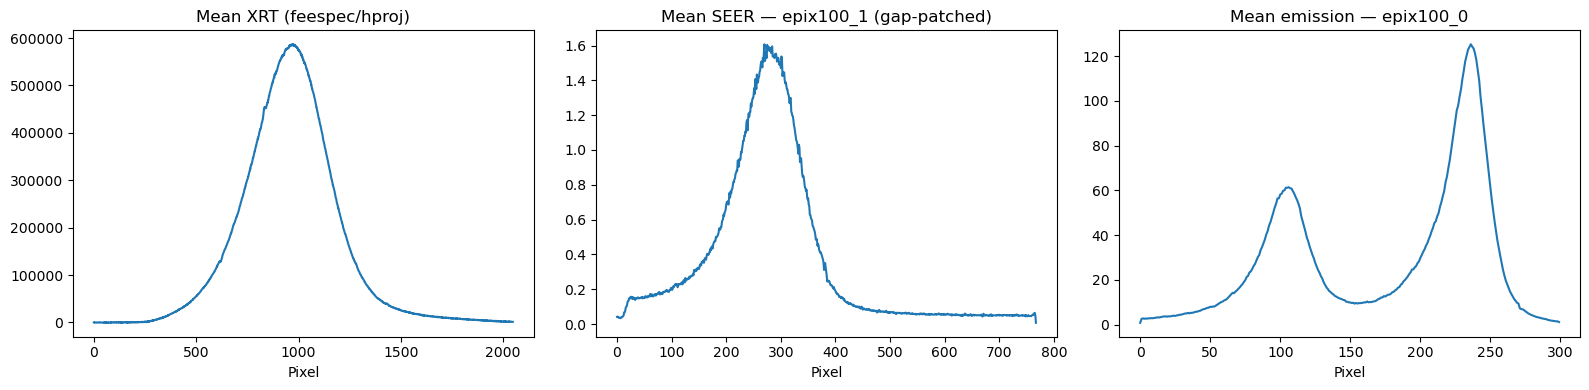

(dropped 1151 low-signal shots from CoM diagnostics)
XRT  CoM jitter: 124.77 px  (18.67%)
SEER CoM jitter: 39.54 px  (13.86%)

corr(XRT CoM,  SEER CoM):   0.978   <- does SEER track the incident beam?
corr(XRT CoM,  emission):   0.774
corr(SEER CoM, emission):   0.785
corr(XRT sum,  SEER sum):   0.826   <- intensity tracking


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(xrt_raw.mean(0));   axes[0].set_title('Mean XRT (feespec/hproj)')
axes[1].plot(epix_seer.mean(0)); axes[1].set_title('Mean SEER — epix100_1 (gap-patched)')
axes[2].plot(epix_spec.mean(0)); axes[2].set_title('Mean emission — epix100_0')
for a in axes: a.set_xlabel('Pixel')
plt.tight_layout(); plt.show()

def com(M, lo=0, hi=None):
    """Per-shot centre-of-mass. Returns (com, good) where `good` flags shots
    with enough integrated signal for the CoM to be meaningful. Pooling many
    runs exposes a few near-zero-sum shots (esp. background-subtracted XRT)
    whose CoM would otherwise explode and corrupt the jitter/correlation."""
    sub = M[:, lo:hi]
    px  = np.arange(sub.shape[1], dtype=float)
    tot = sub.sum(1)
    good = tot > 0.05 * np.median(tot[tot > 0])   # drop low-signal shots
    c = (sub @ px) / np.where(tot != 0, tot, 1)
    return c, good

XRT_LO, XRT_HI = 301, 1833      # active XRT pixel range
com_xrt,  good_xrt  = com(xrt_raw, XRT_LO, XRT_HI)
com_seer, good_seer = com(epix_seer)
com_spec, good_spec = com(epix_spec)

# Common set of shots where every CoM is well defined
good = good_xrt & good_seer & good_spec
com_xrt, com_seer, com_spec = com_xrt[good], com_seer[good], com_spec[good]
n_drop = int((~good).sum())
if n_drop:
    print(f'(dropped {n_drop} low-signal shots from CoM diagnostics)')

print(f'XRT  CoM jitter: {com_xrt.std():.2f} px  ({100*com_xrt.std()/com_xrt.mean():.2f}%)')
print(f'SEER CoM jitter: {com_seer.std():.2f} px  ({100*com_seer.std()/com_seer.mean():.2f}%)')
print()
print(f'corr(XRT CoM,  SEER CoM):   {np.corrcoef(com_xrt, com_seer)[0,1]:.3f}   <- does SEER track the incident beam?')
print(f'corr(XRT CoM,  emission):   {np.corrcoef(com_xrt, com_spec)[0,1]:.3f}')
print(f'corr(SEER CoM, emission):   {np.corrcoef(com_seer, com_spec)[0,1]:.3f}')
print(f'corr(XRT sum,  SEER sum):   {np.corrcoef(xrt_raw[good].sum(1), epix_seer[good].sum(1))[0,1]:.3f}   <- intensity tracking')

## 3. Build A/B matrices for both incident references

Same recipe as the original notebook:
1. crop/bin the incident spectrum (XRT only — SEER is already small),
2. mean-subtract both `A` and `B` to isolate shot-to-shot fluctuations,
3. contract over the shot dimension → `AtA`, `AtB`, `Tr(BtB)`.

`B` (emission) is shared, so any difference in the recovered RIXS map is due
entirely to the choice of incident reference `A`.

In [4]:
XRT_BIN = 8     # 2048 -> ~191 bins

# --- Emission B (shared) ---
B = epix_spec - epix_spec.mean(0)
TrBtB = float(np.sum(B**2))

# --- Incident A #1: XRT (crop + bin) ---
A_crop = xrt_raw[:, XRT_LO:XRT_HI]
n_bins = A_crop.shape[1] // XRT_BIN
A_binned = A_crop[:, :n_bins*XRT_BIN].reshape(A_crop.shape[0], n_bins, XRT_BIN).sum(2)
A_xrt = A_binned - A_binned.mean(0)

# --- Incident A #2: SEER (crop to the active emission line, then bin) ---
# The full 768-col SEER frame has dead panel area at both ends (the signal
# only spans full-panel cols ~160-400; the ramp-off at the extremes is the
# -1.6 deg rotation swinging signal rows out of the summed row band). Cropping
# to the active window removes ~7.5% pure-noise variance and drops cond(AtA)
# from ~3.5e3 to ~6e2, mirroring the XRT arm's XRT_LO:XRT_HI crop.
SEER_LO, SEER_HI = 160, 400      # active SEER full-panel column range
SEER_BIN = 4
seer_crop = epix_seer[:, SEER_LO:SEER_HI]
ns = seer_crop.shape[1] // SEER_BIN
S_binned = seer_crop[:, :ns*SEER_BIN].reshape(seer_crop.shape[0], ns, SEER_BIN).sum(2)
A_seer = S_binned - S_binned.mean(0)

# Patched ASIC gap columns (full-panel) that fall inside the SEER crop. The
# polynomial patch reconstructs each gap column as a smooth interpolation of
# its neighbors, making it collinear with them on a per-shot basis. spook
# therefore cannot assign independent incident-energy weight to these columns
# and leaves a sharp low-intensity STRIPE in the RIXS map at each one. These
# are gap-patch ARTIFACTS, not physics -> flag their binned indices so we can
# mark/ignore them downstream.
GAP_COLS_FULL = [191, 287, 383]                       # gaps within [160,400)
seer_gap_bins = [int((g - SEER_LO) // SEER_BIN) for g in GAP_COLS_FULL]

def contract(A, B):
    return A.T @ A, A.T @ B

AtA_xrt,  AtB_xrt  = contract(A_xrt,  B)
AtA_seer, AtB_seer = contract(A_seer, B)

print(f'XRT  A: {A_xrt.shape}   AtA cond: {np.linalg.cond(AtA_xrt):.2e}')
print(f'SEER A: {A_seer.shape}   AtA cond: {np.linalg.cond(AtA_seer):.2e}  (cropped {SEER_LO}-{SEER_HI})')
print(f'SEER gap-artifact bins (mask in plots): {seer_gap_bins}')
print(f'Shared B: {B.shape}   Tr(BtB)={TrBtB:.3e}')

XRT  A: (10533, 191)   AtA cond: 4.47e+07
SEER A: (10533, 60)   AtA cond: 5.80e+02  (cropped 160-400)
SEER gap-artifact bins (mask in plots): [7, 31, 55]
Shared B: (10533, 300)   Tr(BtB)=2.314e+09


## 4. Solve spook for each incident reference

Fast L2 solve (`SpookLinSolve`) for both. Same `lsmooth` so the comparison is fair.
Switch to `SpookPosL1` for the physically-correct non-negative+sparse solution.

In [5]:
LSMOOTH = (1e-3, 1e-3)

spk_xrt = SpookLinSolve(AtB_xrt, AtA_xrt, mode='contracted', lsmooth=LSMOOTH)
spk_xrt.set_btb(TrBtB)
X_xrt = spk_xrt.getXopt()

spk_seer = SpookLinSolve(AtB_seer, AtA_seer, mode='contracted', lsmooth=LSMOOTH)
spk_seer.set_btb(TrBtB)
X_seer = spk_seer.getXopt()

print(f'XRT  RIXS map: {X_xrt.shape}   max={X_xrt.max():.3e}')
print(f'SEER RIXS map: {X_seer.shape}   max={X_seer.max():.3e}')

XRT  RIXS map: (191, 300)   max=1.015e-06
SEER RIXS map: (60, 300)   max=1.016e+00


## 5. Compare the two RIXS maps side-by-side

**Note on the SEER stripes.** The sharp low-intensity vertical stripes in the
SEER RIXS map (dotted lines, full-panel cols ~191, 287, 383) sit exactly on the
patched ASIC gap columns. The polynomial gap-patch rebuilds each dead column as
a smooth interpolation of its neighbors, so on a per-shot basis it is collinear
with them; spook cannot assign independent incident-energy weight to a column
that is a linear combination of others, leaving a stripe of missing intensity.
These are **gap-patch artifacts, not physics** — the emission-axis lineout
(section 6) is unaffected because it collapses the incident axis.

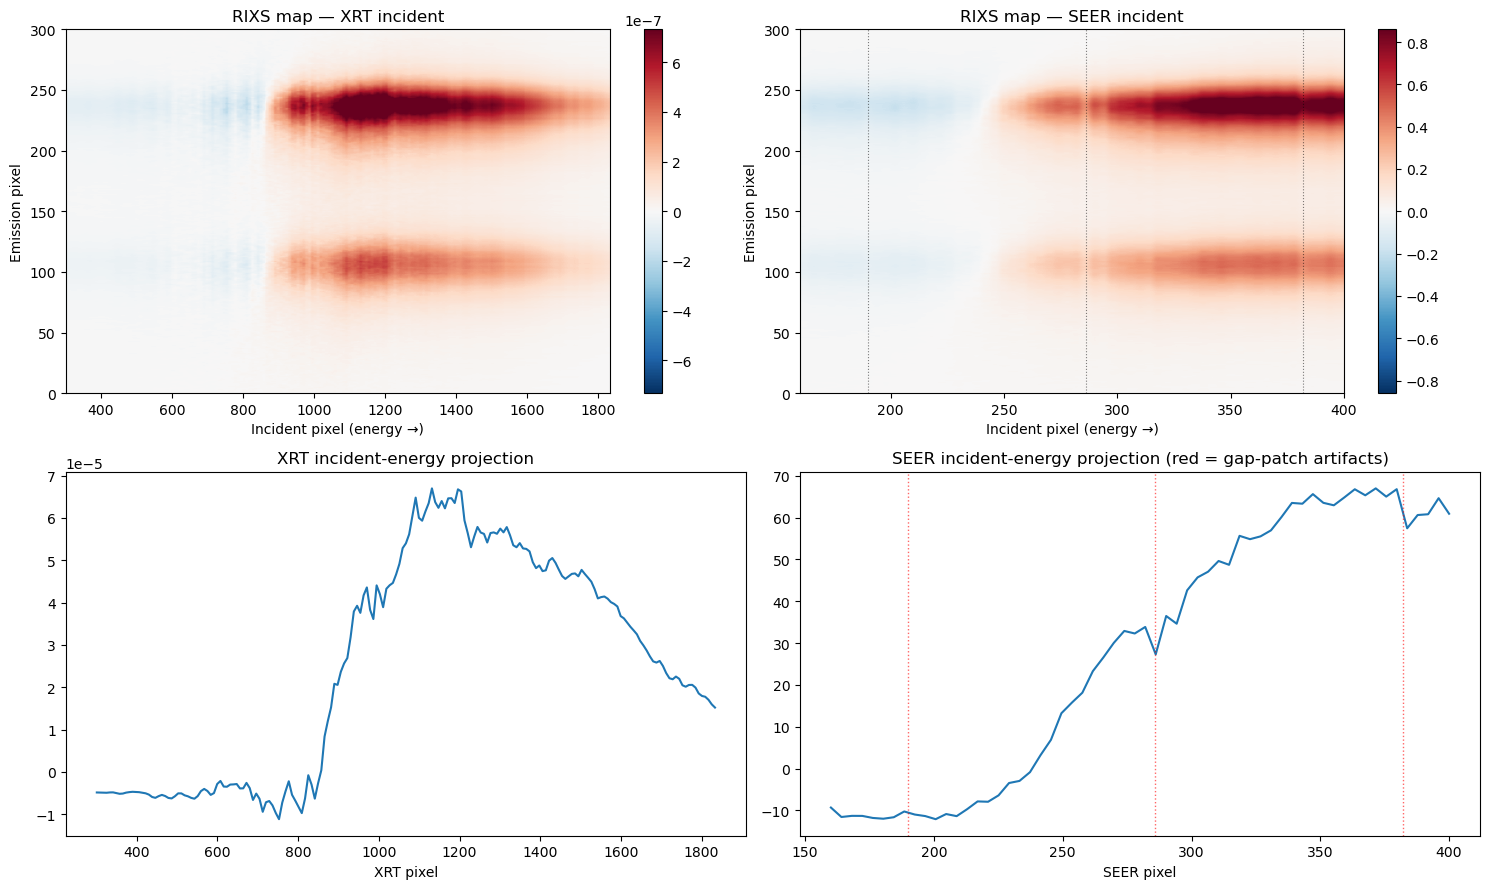

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# full-panel pixel positions of the flagged gap-artifact stripes
seer_gap_px = [SEER_LO + (b + 0.5) * SEER_BIN for b in seer_gap_bins]

for ax, X, title, extent, gaps_px in [
    (axes[0, 0], X_xrt,  'RIXS map — XRT incident',  [XRT_LO, XRT_HI, 0, B.shape[1]], []),
    (axes[0, 1], X_seer, 'RIXS map — SEER incident', [SEER_LO, SEER_HI, 0, B.shape[1]], seer_gap_px),
]:
    v = np.percentile(np.abs(X), 99)
    im = ax.imshow(X.T, aspect='auto', origin='lower', extent=extent,
                   cmap='RdBu_r', vmin=-v, vmax=v)
    plt.colorbar(im, ax=ax)
    for gx in gaps_px:
        ax.axvline(gx, color='k', ls=':', lw=0.8, alpha=0.5)
    ax.set_xlabel('Incident pixel (energy →)'); ax.set_ylabel('Emission pixel')
    ax.set_title(title)

# Incident-energy projections
axes[1, 0].plot(np.linspace(XRT_LO, XRT_HI, X_xrt.shape[0]), X_xrt.sum(1))
axes[1, 0].set_title('XRT incident-energy projection'); axes[1, 0].set_xlabel('XRT pixel')
axes[1, 1].plot(np.linspace(SEER_LO, SEER_HI, X_seer.shape[0]), X_seer.sum(1))
for gx in seer_gap_px:
    axes[1, 1].axvline(gx, color='r', ls=':', lw=1, alpha=0.6)
axes[1, 1].set_title('SEER incident-energy projection (red = gap-patch artifacts)')
axes[1, 1].set_xlabel('SEER pixel')
plt.tight_layout(); plt.show()

## 6. Quantitative comparison

Compare emission-axis lineouts (collapse the incident axis). If SEER is a good
incident monitor, its recovered emission profile should match XRT's. The
residual norm `||B - A X||` (reconstruction error) is the spook objective —
lower means the incident reference explains the emission fluctuations better.

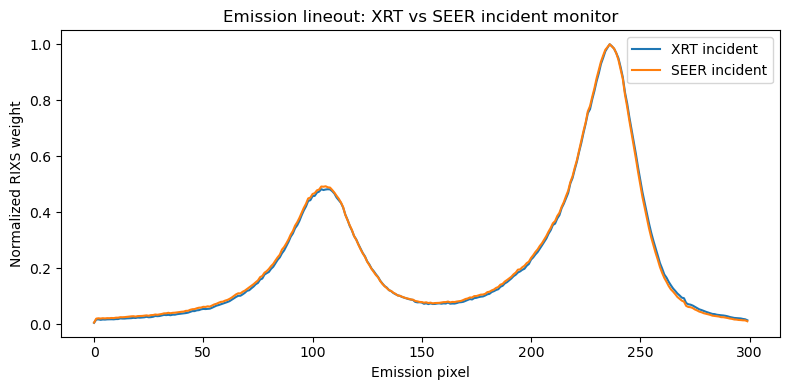

Relative residual  ||B-AX||/||B||:   XRT=0.3271   SEER=0.3681
Emission-lineout correlation (XRT vs SEER): 1.000

Interpretation:
  * lower residual  -> incident reference better explains emission fluctuations
  * high lineout corr -> SEER recovers the same RIXS emission structure as XRT


In [7]:
emiss_xrt  = X_xrt.sum(0)
emiss_seer = X_seer.sum(0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(emiss_xrt  / np.abs(emiss_xrt).max(),  label='XRT incident')
ax.plot(emiss_seer / np.abs(emiss_seer).max(), label='SEER incident')
ax.set_xlabel('Emission pixel'); ax.set_ylabel('Normalized RIXS weight')
ax.set_title('Emission lineout: XRT vs SEER incident monitor')
ax.legend(); plt.tight_layout(); plt.show()

def residual(A, X, B):
    return float(np.linalg.norm(B - A @ X) / np.linalg.norm(B))

r_xrt  = residual(A_xrt,  X_xrt,  B)
r_seer = residual(A_seer, X_seer, B)
lc = np.corrcoef(emiss_xrt, emiss_seer)[0, 1]
print(f'Relative residual  ||B-AX||/||B||:   XRT={r_xrt:.4f}   SEER={r_seer:.4f}')
print(f'Emission-lineout correlation (XRT vs SEER): {lc:.3f}')
print()
print('Interpretation:')
print('  * lower residual  -> incident reference better explains emission fluctuations')
print('  * high lineout corr -> SEER recovers the same RIXS emission structure as XRT')

## Notes

- **Droplet vs ADU:** rerun `mfx101609126_spook_rixs.ipynb` (ADU `ROI_area`) and compare
  the residuals here to quantify the S/N gain from photon-counting.
- **SEER as incident monitor:** the section-2 `corr(XRT CoM, SEER CoM)` is the key number.
  If it is high, SEER genuinely tracks the incident-energy jitter and the two RIXS maps
  should agree; if low, SEER is dominated by its own emission/self-absorption and is not
  a clean incident reference.
- **Positivity:** swap `SpookLinSolve` -> `SpookPosL1(..., lsparse=1.0, lsmooth=(0.1,0.1))`
  for the physical non-negative map (slower; keep `XRT_BIN >= 8`).
- **Hyperparameters:** `spk.getXopt(lsmooth=(x, y))` re-solves cheaply without recontracting
  `AtA`/`AtB`, so a sweep is fast.